In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Processing

## Loading Files

In [7]:
def string_to_tuple(tuple_string):
    return (int(tuple_string[0]), int(tuple_string[1]))

def pattern_string_to_tuple_list(pattern_string):
    return sorted([string_to_tuple(s) for s in [c.replace('[', '').replace(';','').replace(']','').replace(',','') for c in pattern_string.split(' ')]])

def patterns_from_txt(filepath) -> list[list[tuple[int,int]]]:
    patterns = []
    with open(filepath, 'r') as file:
        lines = file.readlines()
        for line in lines:
            patterns.append(pattern_string_to_tuple_list(line))
    return patterns

Load all stats.csv files into their respective dataframes, load pattern int tuple lists

In [17]:
ind_dataframes:list[pd.DataFrame] = [] 
pattern_lists:list[list[tuple[int,int]]] = []
N_TOTAL_BATCHES = 5
for i in range(N_TOTAL_BATCHES):
    ind_dataframes.append(pd.read_csv(f'stats_{i+1}.csv'))
    pattern_lists.append(patterns_from_txt(f'patterns_{i+1}.txt'))


In [21]:
pattern_dicts: list[dict[int,list[tuple[int,int]]]] = []
for i in range(N_TOTAL_BATCHES):
    pattern_dicts.append(dict())
    for i_p, pattern in enumerate(pattern_lists):
        pattern_dicts[i][i_p] = pattern

Create new "processed" dataframes 

In [25]:
for i in range(N_TOTAL_BATCHES):
    ind_dataframes[i]['original_pattern'] = [pattern_string_to_tuple_list(s) for s in ind_dataframes[i]['original_pattern']]
    ind_dataframes[i]['OP_i'] = [pattern_lists[i].index(s) for s in ind_dataframes[i]['original_pattern']]
    print(ind_dataframes[i].head())

   N_dist  reconstr_success  \
0       3              True   
1       3              True   
2       3              True   
3       3              True   
4       3              True   

                                    original_pattern  \
0  [(0, 5), (1, 6), (2, 2), (3, 0), (4, 0), (5, 3...   
1  [(0, 6), (1, 5), (2, 1), (3, 2), (4, 3), (5, 5...   
2  [(0, 3), (1, 4), (2, 0), (3, 6), (4, 7), (5, 0...   
3  [(0, 3), (1, 3), (2, 0), (3, 0), (4, 7), (5, 7...   
4  [(0, 4), (1, 5), (2, 5), (3, 0), (4, 3), (5, 7...   

                                   distorted_pattern  OP_i  
0  [[2;4], [8;5], [7;2], [1;6], [3;0], [6;1], [4;...    19  
1  [[0;3], [2;3], [6;2], [1;5], [7;4], [4;3], [8;...    13  
2  [[4;8], [1;8], [6;3], [7;2], [8;3], [5;0], [3;...    14  
3  [[4;0], [7;0], [6;0], [5;7], [0;3], [8;2], [3;...    12  
4  [[2;0], [7;3], [4;4], [3;0], [5;7], [0;4], [6;...    11  
   N_dist  reconstr_success  \
0       3              True   
1       3              True   
2       3        

for each batch: create dict where index -> sucess rate

# Data Analysis

for batches 1, 2, 5: plot success rate for each pattern in function of index

In [26]:
success_dicts: list[dict[int,float]] = []
for i in range(N_TOTAL_BATCHES):
    success_dicts.append(dict())
    for i_pattern in range(20):
        current_slice_df = ind_dataframes[i][ind_dataframes[i]['OP_i'] == i_pattern]
        success_dicts[i][i_pattern] = len(current_slice_df[current_slice_df['reconstr_success'] == True]) / len(current_slice_df)

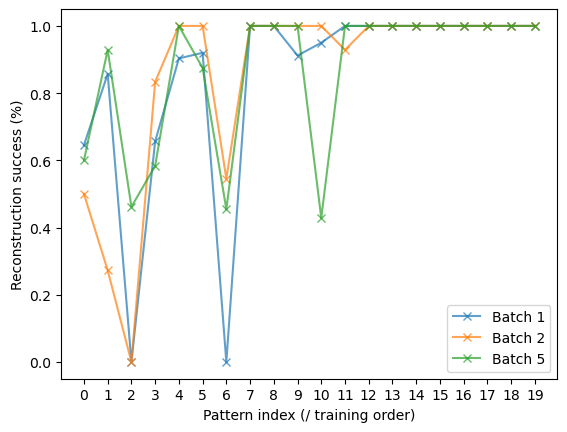

In [33]:
for i in [0, 1, 4]:
    plt.plot(range(20), [success_dicts[i][i_p] for i_p in range(20)], label=f'Batch {i+1}', marker='x', alpha=0.7)
plt.xlabel('Pattern index (/ training order)')
plt.xticks(np.arange(0, 20, 1))
plt.ylabel('Reconstruction success (%)')
plt.legend()
plt.show()